In [1]:

# H1: Properties located at specific geographic coordinates (latitude and longitude) 
#     that are not waterfront are more likely to provide large lot sizes, making them 
#     suitable for luxury outdoor amenities such as pools, tennis courts, and golf facilities.

# H2: Properties that meet luxury space requirements are characterized by either having at least 
#     four bathrooms (absolute size indicator) or having a larger living area than neighboring 
#     properties (relative size indicator).

# H3: Properties that are historically older are more likely to meet client preferences when they 
#     are in good condition and have not been renovated, preserving their original architectural character.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [3]:
# read the data frame
df = pd.read_csv('king_county_house_pandas_filled.csv')

In [4]:
# find a threshold for lot area by finding top 5% of sqft_lot
lot_thre = df['sqft_lot'].quantile(0.95)
lot_thre

np.float64(43307.200000000026)

In [5]:
historic_thre = 70
df[df['house_age'] > historic_thre]

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,house_age,is_renovated
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,0.0,0.0,3,7,...,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0,71,0
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,1991.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0,75,1
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,0.0,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0,93,0
11,9212900260,2.0,1.00,1160.0,6000.0,1.0,0.0,0.0,4,7,...,0.0,98115,47.6900,-122.292,1330.0,6000.0,2014-05-27,468000.0,84,0
12,114101516,3.0,1.00,1430.0,19901.0,1.5,0.0,0.0,4,7,...,0.0,98028,47.7558,-122.229,1780.0,12697.0,2014-05-28,310000.0,99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21224,7174800094,1.0,1.50,1030.0,5923.0,1.0,0.0,0.0,3,8,...,0.0,98105,47.6653,-122.305,2650.0,5000.0,2015-04-20,525000.0,86,0
21316,9266700190,1.0,1.00,390.0,2000.0,1.0,0.0,0.0,4,6,...,0.0,98103,47.6938,-122.347,1340.0,5100.0,2015-05-11,245000.0,106,0
21327,2924079034,3.0,1.50,2580.0,47480.0,1.0,0.0,0.0,3,7,...,0.0,98024,47.5333,-121.933,1760.0,48181.0,2014-09-25,332220.0,73,0
21454,121039156,3.0,1.00,1030.0,24750.0,1.0,0.0,2.0,3,5,...,0.0,98023,47.3343,-122.362,2810.0,28800.0,2015-01-09,249000.0,83,0


In [6]:
condition_thre = np.median(df['condition'].unique())
condition_thre

np.float64(3.0)

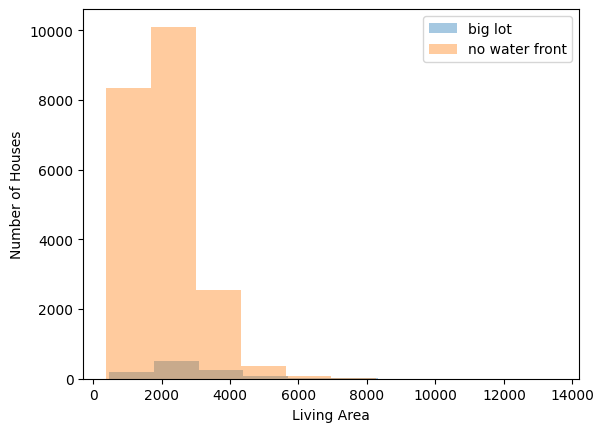

In [7]:
# Flags for Hypo 1:  
# House in lat/long that have a big lot, but no waterfront
df_Hypo1a = df[df['sqft_lot'] > lot_thre]
df_Hypo1b = df[df['waterfront'] == 0]

plt.hist(df_Hypo1a['sqft_living'], label='big lot',alpha=0.4)
plt.hist(df_Hypo1b['sqft_living'], label='no water front',alpha=0.4)
plt.xlabel('Living Area')
plt.ylabel('Number of Houses')
plt.legend()


In [8]:
# Hypo1 full:
df_Hypo1 = df[(df['sqft_lot'] > lot_thre) & (df['waterfront'] == 0)]

g = sns.catplot(
    data=df_Hypo1,
    y='house_age',
    x='bathrooms',
    col='if_renovated',
    kind='box'
)

# Loop through each subplot 
for ax in g.axes.flat:
    # Add vertical line (as bathrooms > = 4)
    ax.axvline(x=12, color='red', linestyle='--', label='num of bath thre')
    
    # Add horizontal line (as house age > historic_thre)
    ax.axhline(y=historic_thre, color='green', linestyle='--', label='house age thre')
    
    ax.legend()

    # Rotate x-ticks
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.show()


ValueError: Could not interpret value `if_renovated` for `col`. An entry with this name does not appear in `data`.

In [ ]:
plot_data = df[df['waterfront'] == 0].copy()
plot_data['big_lot'] = plot_data['sqft_lot'] > lot_thre
plot_data['size_scaled'] = plot_data['sqft_lot'] / 10000

# Create map
fig = px.scatter_mapbox(
    plot_data,
    lat="lat",
    lon="long",
    size="size_scaled",
    color="big_lot",  # to highlight large lots
    hover_data={
        "price": True,
        "sqft_living": True,
        "sqft_lot": True,
        "bathrooms": True,
        "lat": False,
        "long": False
    },
    zoom=9,
    height=700,
    title="Geographical Distribution of Houses (Size = Lot Size, No Waterfront)"
)

# Map style
fig.update_layout(
    mapbox_style="open-street-map"
)

fig.show()

/var/folders/3l/slblcrbj32b37hg9lcbsc9fc0000gn/T/ipykernel_2061/204706378.py:6: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


Text(0, 0.5, 'Number of houses')

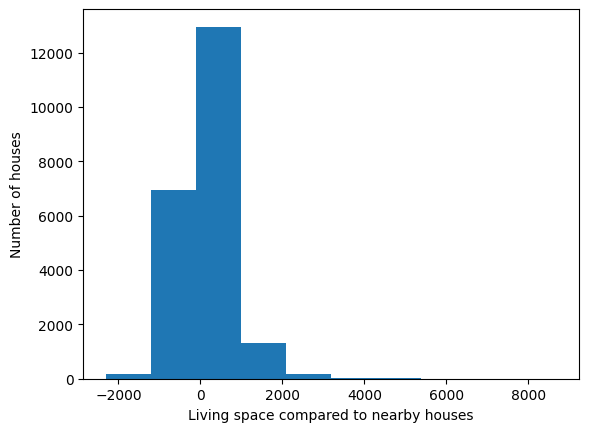

In [ ]:
# set threshold for larger than surrounding houses
df['locally_dominant'] = df['sqft_living'] - df['sqft_living15']
plt.hist(df['sqft_living'] - df['sqft_living15'])
plt.xlabel('Living space compared to nearby houses')
plt.ylabel('Number of houses')



Text(0, 0.5, 'Number of houses')

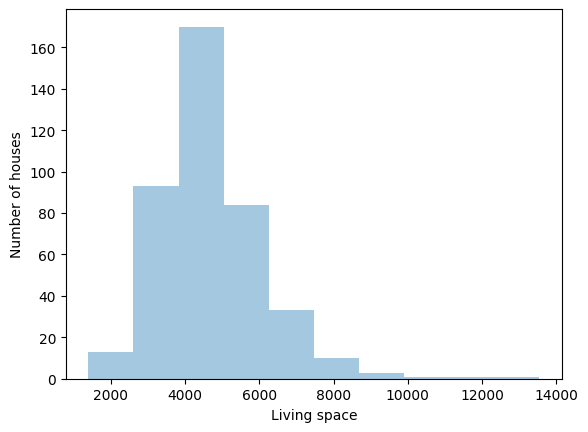

In [ ]:
# set flags for Hypo 2:
# House wiht >= 4 bathrooms, or larger than surrounding houses
dominance_thre = 3500.
df_Hypo2 = df[(df['bathrooms'] >= 4) | (df['locally_dominant'] > dominance_thre)]

plt.hist(df_Hypo2['sqft_living'],alpha=0.4)
plt.xlabel('Living space')
plt.ylabel('Number of houses')


/var/folders/3l/slblcrbj32b37hg9lcbsc9fc0000gn/T/ipykernel_2061/1011039946.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['bigger_than_neighbors'] = plot_data['sqft_living'] > plot_data['sqft_living15']


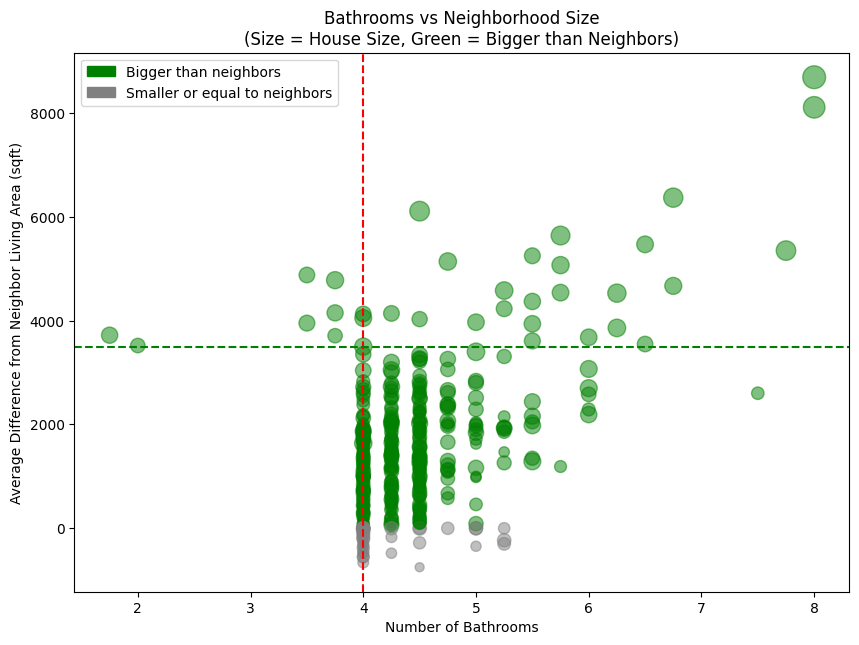

In [ ]:

plot_data = df_Hypo2

# Create dominance flag
plot_data['bigger_than_neighbors'] = plot_data['sqft_living'] > plot_data['sqft_living15']

# Scale marker size 
sizes = plot_data['sqft_living'] / 50

# Create color mapping
colors = plot_data['bigger_than_neighbors'].map({True: 'green', False: 'gray'})

plt.figure(figsize=(10, 7))

plt.scatter(
    plot_data['bathrooms'],        
    plot_data['locally_dominant'],   
    s=sizes,
    c=colors,
    alpha=0.5
)

plt.xlabel("Number of Bathrooms")
plt.ylabel("Average Difference from Neighbor Living Area (sqft)")
plt.title("Bathrooms vs Neighborhood Size\n(Size = House Size, Green = Bigger than Neighbors)")

import matplotlib.patches as mpatches

green_patch = mpatches.Patch(color='green', label='Bigger than neighbors')
gray_patch = mpatches.Patch(color='gray', label='Smaller or equal to neighbors')

plt.legend(handles=[green_patch, gray_patch])
plt.axvline(x=4, color='red', linestyle='--', label='4 bathrooms threshold')
plt.axhline(y=dominance_thre, color='green', linestyle='--', label='dominance threshold')
plt.show()

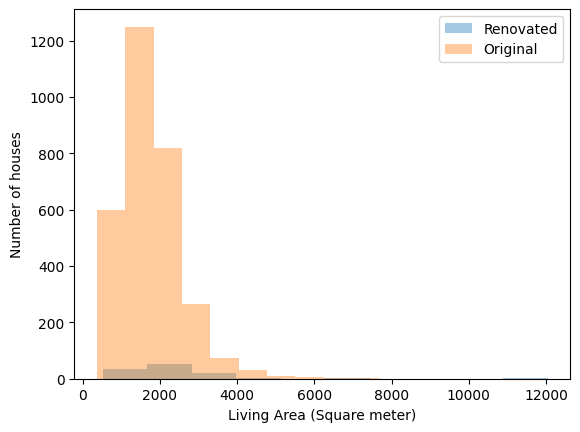

In [ ]:
# set flags for Hypo 3:
# historic house but in great condition either renovated or not renovated (optional)

df_Hypo3_reno = df[(df['house_age'] > historic_thre) & (df['condition'] > condition_thre) & (df['if_renovated'] == 1)]
df_Hypo3_orig = df[(df['house_age'] > historic_thre) & (df['condition'] > condition_thre) & (df['if_renovated'] == 0)]

#df_Hypo3_reno # 41 houses
#df_Hypo3_orig # 784 houses

plt.hist(df_Hypo3_reno['sqft_living'],alpha=0.4, label='Renovated')
plt.hist(df_Hypo3_orig['sqft_living'],alpha=0.4, label='Original')
plt.xlabel('Living Area (Square meter)')
plt.ylabel('Number of houses')

plt.legend()


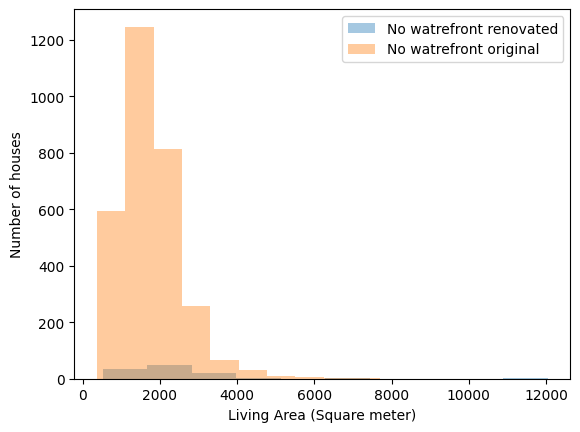

In [ ]:
# Filter by No-waterfront

plt.hist(df_Hypo3_reno[df_Hypo3_reno['waterfront']==0]['sqft_living'],alpha=0.4, label='No watrefront renovated') # 39 houses
plt.hist(df_Hypo3_orig[df_Hypo3_orig['waterfront']==0]['sqft_living'],alpha=0.4, label='No watrefront original') # 780 houses
plt.xlabel('Living Area (Square meter)')
plt.ylabel('Number of houses')

plt.legend()

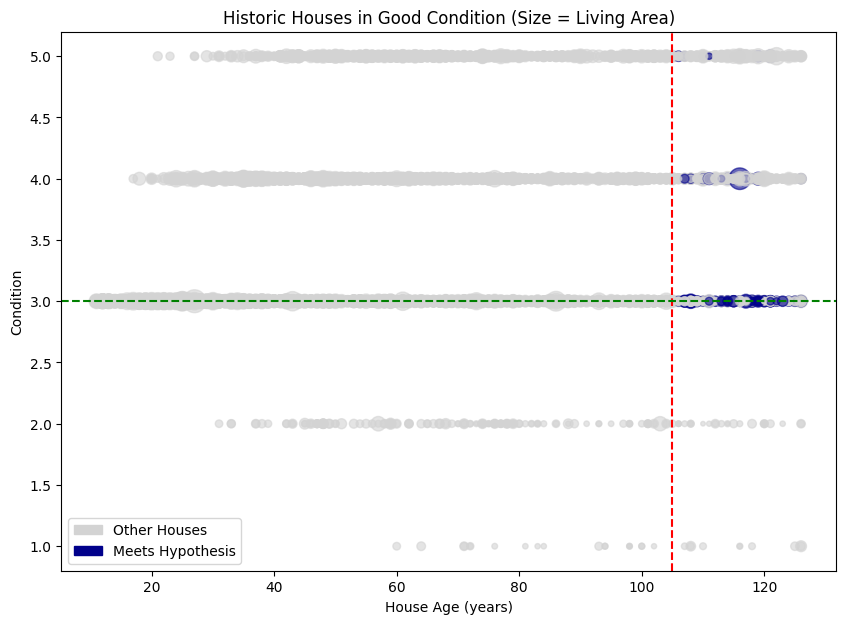

In [ ]:

plot_data = df.copy()

# Flags
plot_data['is_historic'] = plot_data['house_age'] > historic_thre
plot_data['is_good_condition'] = plot_data['condition'] >= condition_thre

# Ideal houses (meeting three conditions of Hypo 1)
plot_data['meets_hypothesis'] = (
    plot_data['is_historic'] &
    plot_data['is_good_condition'] &
    plot_data['if_renovated']
)

# Scale marker size
sizes = plot_data['sqft_living'] / 50

# Color mapping
colors = plot_data['meets_hypothesis'].map({True: 'darkblue', False: 'lightgray'})

plt.figure(figsize=(10, 7))

plt.scatter(
    plot_data['house_age'],
    plot_data['condition'],
    s=sizes,
    c=colors,
    alpha=0.6
)

plt.axvline(x=historic_thre, color='red', linestyle='--', label='Historic threshold')
plt.axhline(y=condition_thre, color='green', linestyle='--', label='Condition threshold')

plt.xlabel("House Age (years)")
plt.ylabel("Condition")
plt.title("Historic Houses in Good Condition (Size = Living Area)")

gray_patch = mpatches.Patch(color='lightgray', label='Other Houses')
blue_patch = mpatches.Patch(color='darkblue', label='Meets Hypothesis')

plt.legend(handles=[gray_patch, blue_patch])

plt.show()

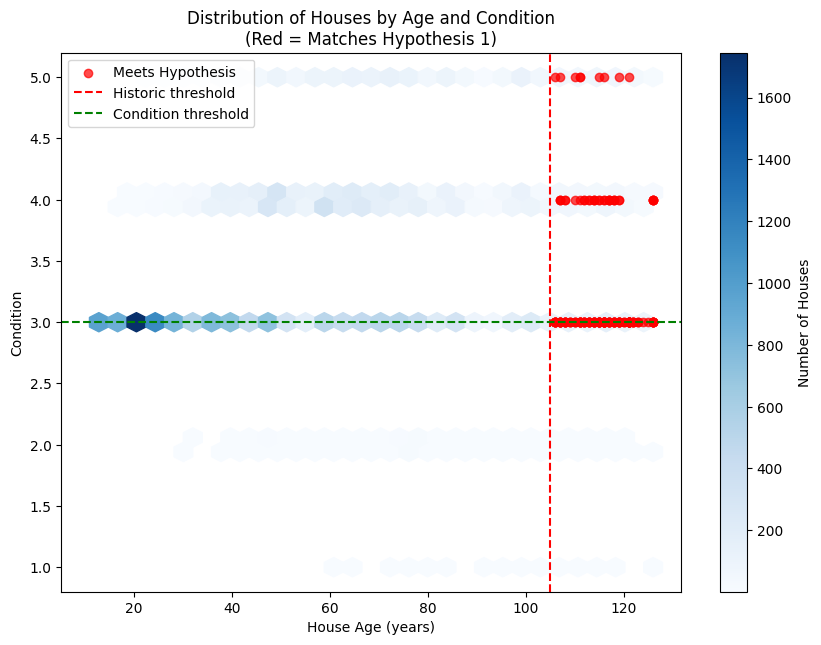

In [ ]:
# The above plot is not easy to read, hexbin plot may solve its legibility issue
plt.figure(figsize=(10, 7))

hb = plt.hexbin(
    plot_data['house_age'],
    plot_data['condition'],
    gridsize=30,
    cmap='Blues',
    mincnt=1
)

# Colorbar (density)
cb = plt.colorbar(hb)
cb.set_label('Number of Houses')

ideal = plot_data[plot_data['meets_hypothesis']]

plt.scatter(
    ideal['house_age'],
    ideal['condition'],
    color='red',
    alpha=0.7,
    label='Meets Hypothesis'
)
plt.axvline(x=historic_thre, color='red', linestyle='--', label='Historic threshold')
plt.axhline(y=condition_thre, color='green', linestyle='--', label='Condition threshold')

plt.xlabel("House Age (years)")
plt.ylabel("Condition")
plt.title("Distribution of Houses by Age and Condition\n(Red = Matches Hypothesis 1)")

plt.legend()
plt.show()

Text(0, 0.5, 'Condition')

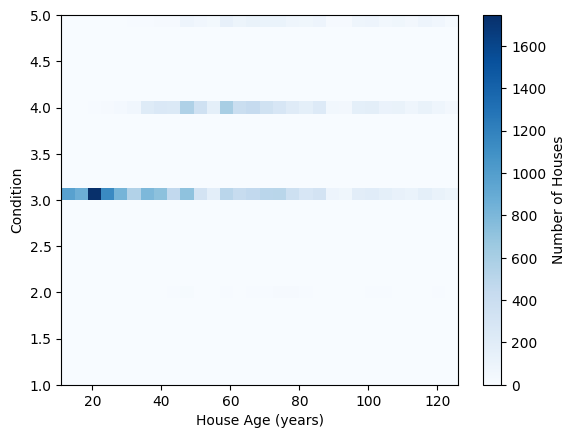

In [ ]:
# or a 2D histogram????
plt.hist2d(
    plot_data['house_age'],
    plot_data['condition'],
    bins=30,
    cmap='Blues'
)
plt.colorbar(label='Number of Houses')
plt.xlabel("House Age (years)")
plt.ylabel("Condition")